
Running alexnet with 128 x 128 SRAM with 22 nm in fast scenario
Running: 0 Computes for layer 1: 137259.375
1 Computes for layer 2: 437400.0
2 Computes for layer 3: 219024.0
3 Computes for layer 4: 292032.0
4 Computes for layer 5: 194688.0
5 Computes for layer 6: 73728.0
6 Computes for layer 7: 32768.0
7 Computes for layer 8: 8000.0

Overall energy for DNN alexnet: 1000000000000017.6 fJ
total_per_energy[alexnet][SRAM][0]: 0.40927671547579925
total_per_energy[alexnet][SRAM][1]: 0.002884164773487174
total_per_energy[alexnet][SRAM][2]: 0.5878202490726243
total_per_energy[alexnet][SRAM][3]: 1.8870678089387633e-05


Running alexnet with 128 x 128 RRAM with 22 nm in fast scenario
Running: 0 Computes for layer 1: 137259.375
1 Computes for layer 2: 437400.0
2 Computes for layer 3: 219024.0
3 Computes for layer 4: 292032.0
4 Computes for layer 5: 194688.0
5 Computes for layer 6: 73728.0
6 Computes for layer 7: 32768.0
7 Computes for layer 8: 8000.0

Overall energy for DNN alexnet: 100000000000

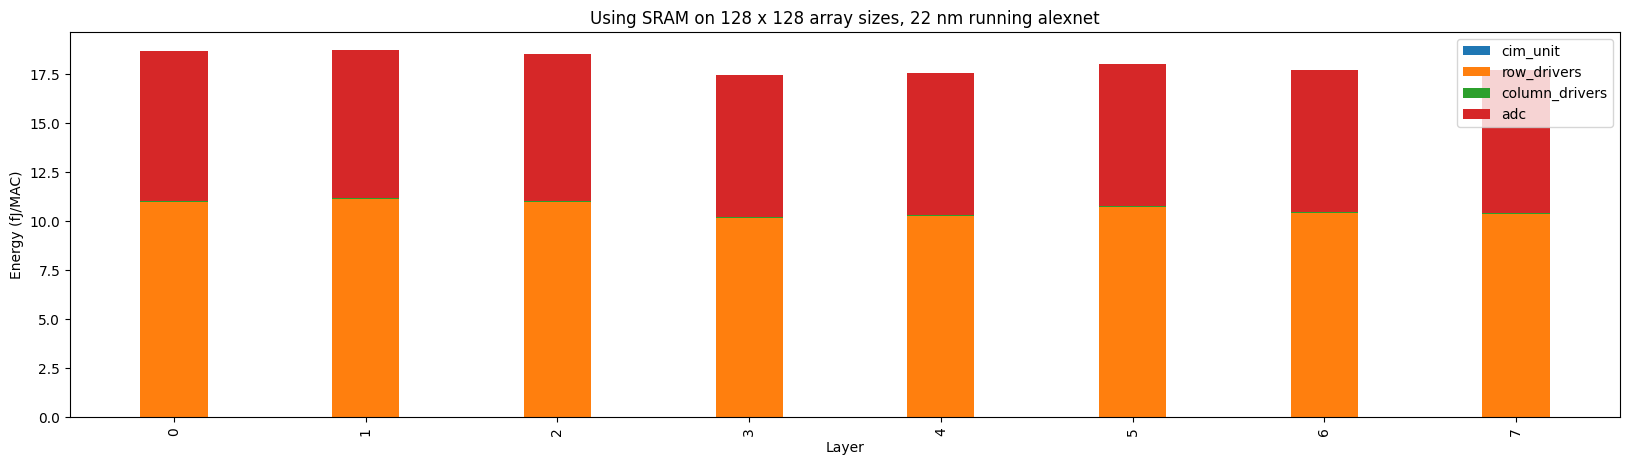

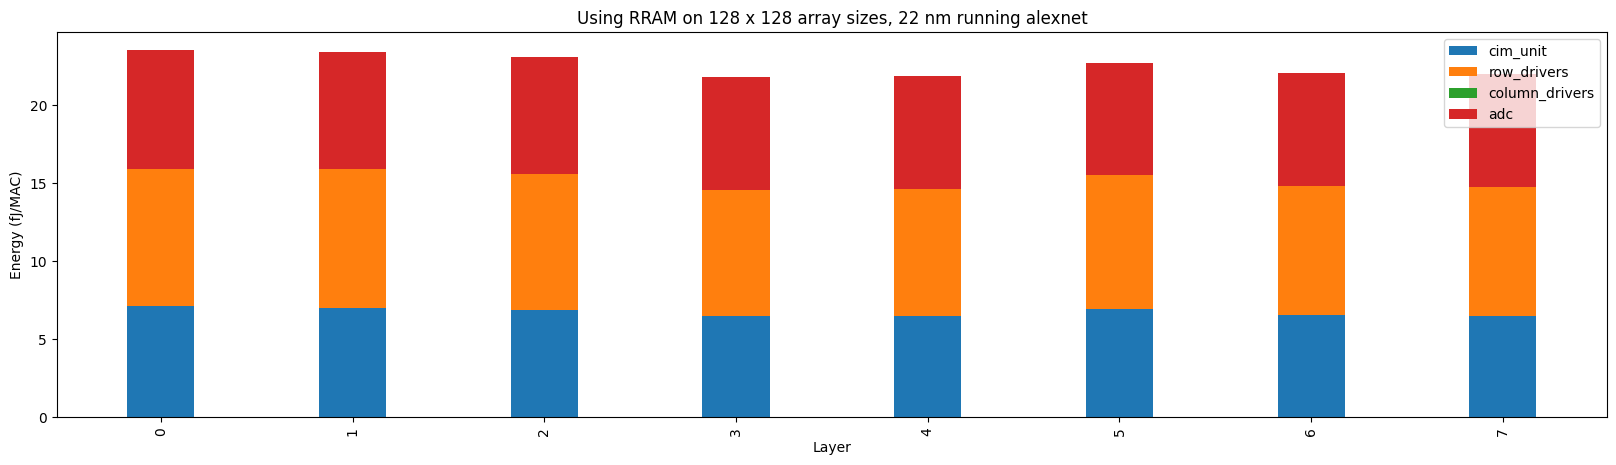

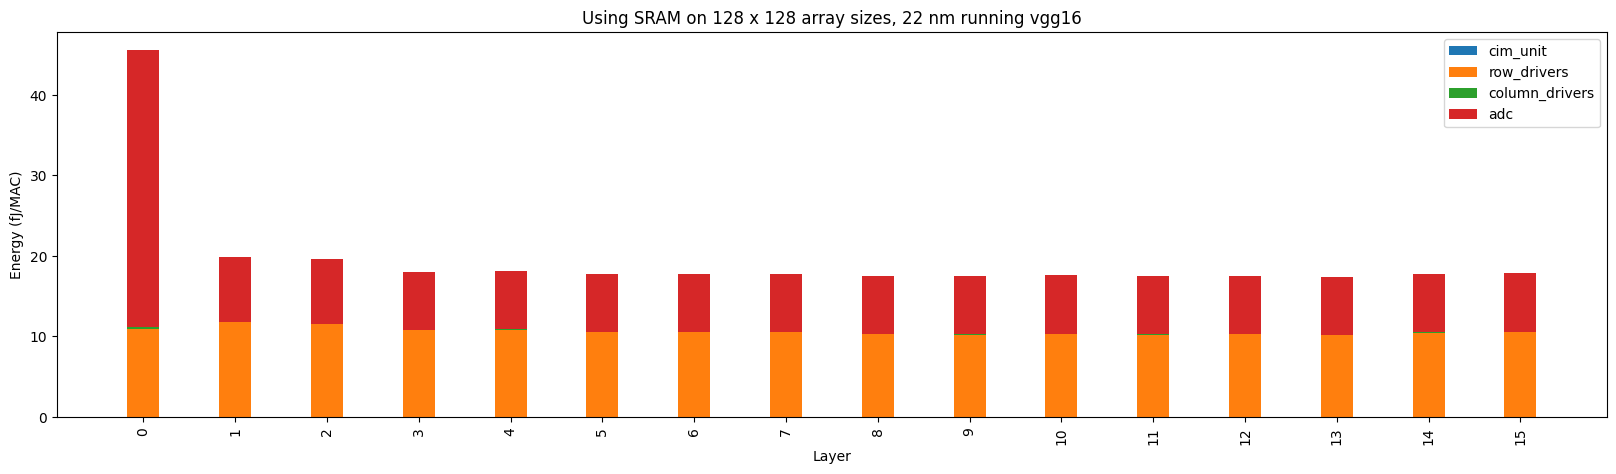

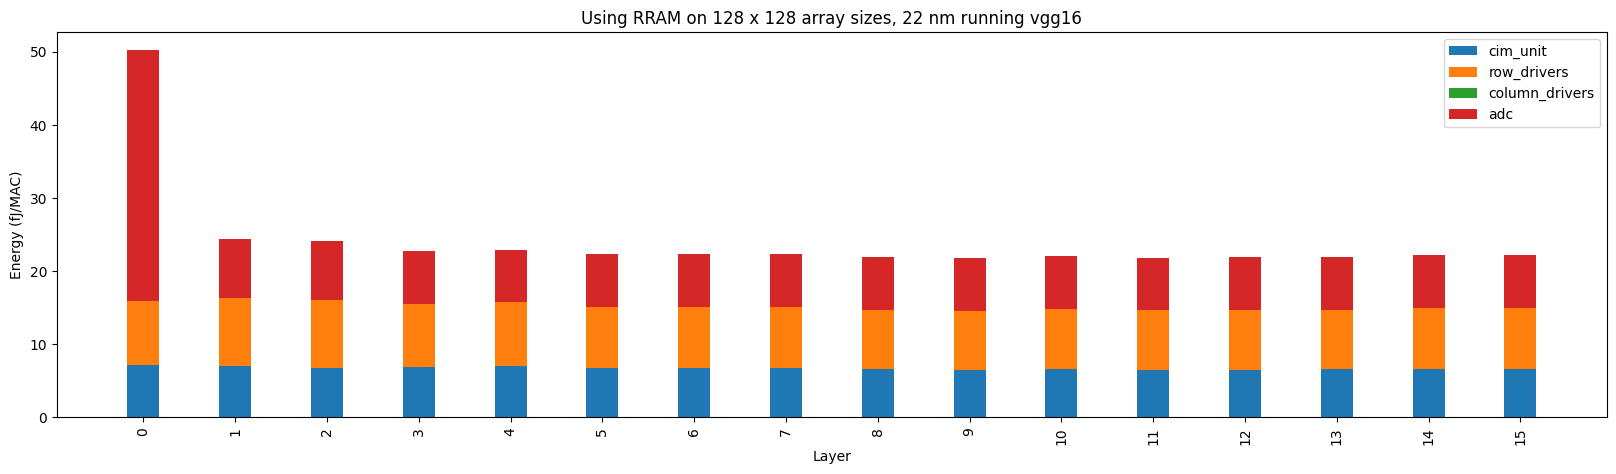

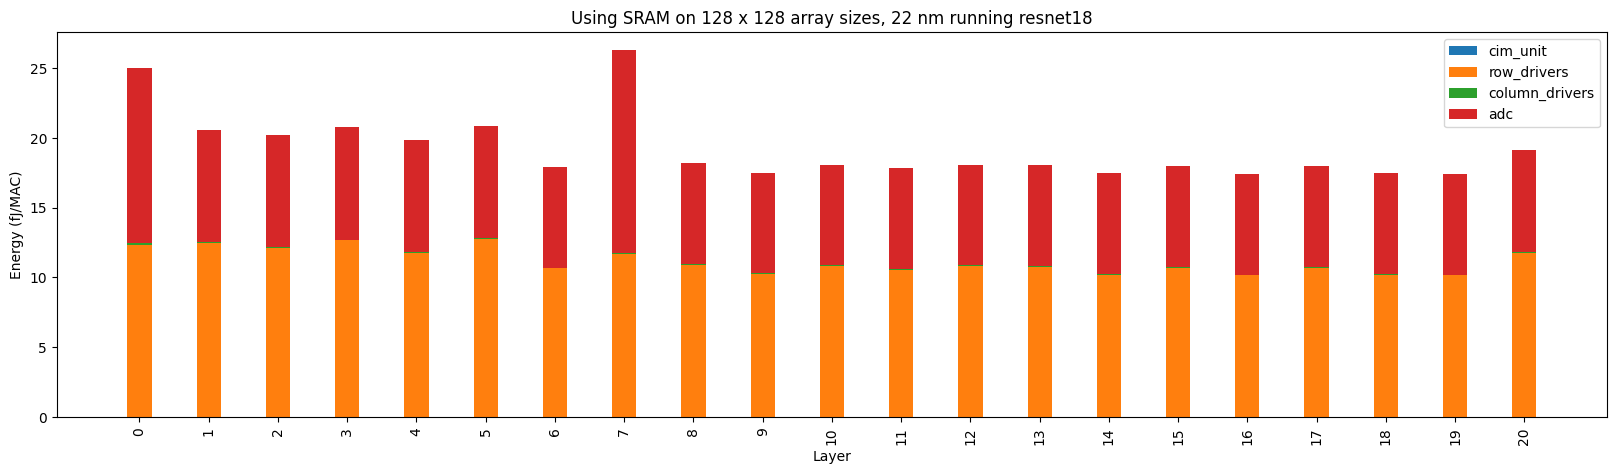

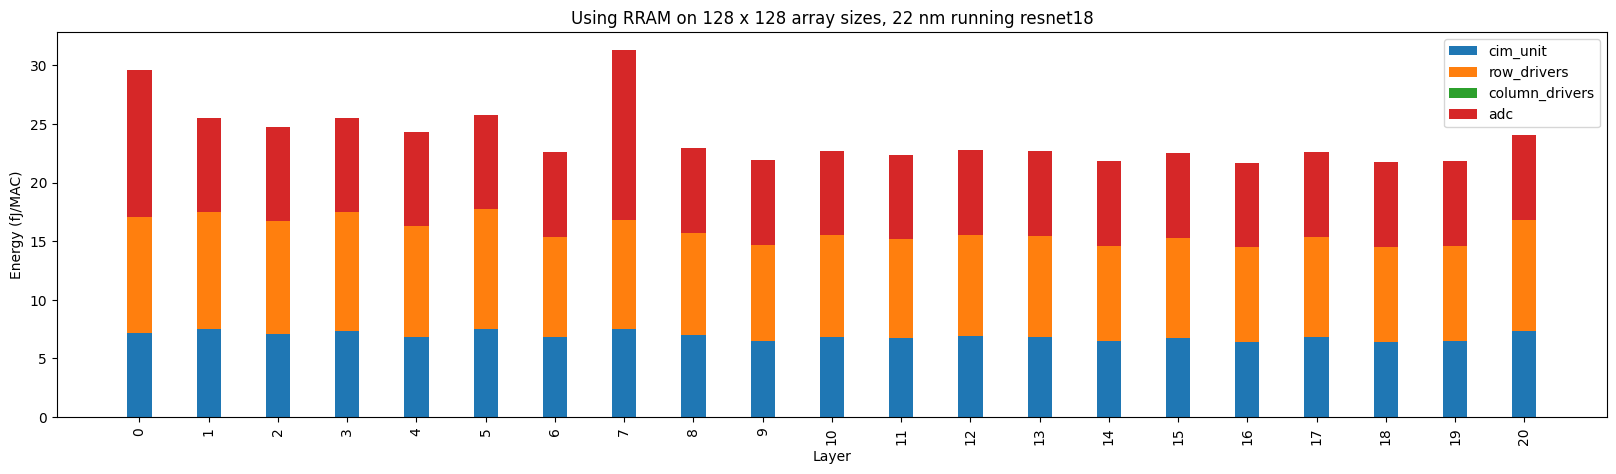

In [2]:
from _import_scripts import scripts
from scripts.notebook_utils import *
from scripts.tl_output_parsing import MacroOutputStats
from scripts.utils import *
import yaml

MACRO_PATH = "../models/arch/1_macro/basic_analog/" 
macro = {}
total_per_energy = {}
SRAM_PATH = f'"{os.path.abspath("../models/memory_cells/sram_example.cell.yaml")}"'
RRAM_PATH = f'"{os.path.abspath("../models/memory_cells/rram_example.cell.yaml")}"'

dnn_layers = {
    "alexnet": 8,
    "vgg16": 16,
    "dpt_large": 227,
    "gpt2_medium": 145,
    "mobilebert": 409,
    "vision_transformer": 98,
    "resnet18": 21,
    "mobilenet_v3": 64
}

# Define the architecture
array_sizes = 128
path_list = [SRAM_PATH, RRAM_PATH]
tech_node = 22
time = "fast"

dnn_list = ["alexnet", "vgg16", "resnet18"]
for DNN in dnn_list:
    dnn_layer = dnn_layers.get(DNN, None)
    def create_layer_directory(base_output_dir: str, architecture: str, layer: int) -> str:
        layer_dir = os.path.join(base_output_dir, f"{architecture}_layer_{layer}")
        if not os.path.exists(layer_dir):
            os.makedirs(layer_dir)
        return layer_dir

    num_layers = 1

    def run_map(
        spec: tl.Specification,
        arch: str,
        accelergy_verbose: bool = False,
    ) -> dict:
        output_dir = get_run_dir()
        # Just use the directory name if it causes error
        base_output_dir = os.path.dirname(output_dir)
        base_output_dir = os.path.join(base_output_dir, arch)
        global num_layers

        mapper_result = None

        if num_layers < dnn_layer+1:
            # Create a directory for the current layer
            layer_dir = create_layer_directory(base_output_dir, arch, num_layers)
            # print(f"Layer directory: {layer_dir}")
            num_layers += 1

            run_prefix = f"{layer_dir}/timeloop-mapper"
            mapper_result = tl.call_mapper(
                specification=spec,
                output_dir=layer_dir,
                log_to=os.path.join(output_dir, f"{run_prefix}.log"),
            )
            if accelergy_verbose:
                tl.call_accelergy_verbose(
                    specification=spec,
                    output_dir=layer_dir,
                    log_to=os.path.join(output_dir, "accelergy.log"),
                )

        if mapper_result is None:
            # Handle case when mapper_result is not assigned (num_layers >= 17)
            # Raise an error, return a default value
            print("Warning: mapper_result is not assigned. num_layers >= 17")
            return {}

        return MacroOutputStats.from_output_stats(mapper_result)

    import re

    def extract_range(line):
        match = re.search(r'\[(\d+):(\d+)(,\d+)?\)', line)
        if match:
            start = int(match.group(1))
            end = int(match.group(2))
            return end - start
        return None

    def read_and_compute_multiplication(filename, i):
        filename = f"../outputs/{filename}/{filename}_layer_{i+1}/timeloop-mapper.map.txt"
        with open(filename, 'r') as file:
            lines = file.readlines()

        start_searching = False
        ranges = []

        for line in lines:
            # Start searching when 'inter_macro_in_system_spatial' is found
            if "inter_macro_in_system_spatial" in line:
                start_searching = True
            
            # Stop searching if we leave the 'inter_macro_in_system_spatial' section
            elif start_searching and "inter_" in line and "inter_macro_in_system_spatial" not in line:
                break

            # If we are in the 'inter_macro_in_system_spatial' section, look for the ranges
            if start_searching:
                if "for" in line:
                    range_size = extract_range(line)
                    if range_size is not None:
                        ranges.append(range_size)
                elif line.strip() == "":  # Exit the section on an empty line
                    break

        # Compute the multiplication of all ranges, or return 1 if no ranges were found
        if not ranges:
            print(f"All macro: 1")
            return 1

        result = 1
        for size in ranges:
            result *= size
            print(f"Size: {size}")
        print(f"All macro: {result}")
        return result


    def extract_layer_number(folder_name):
        match = re.search(r'layer_(\d+)', folder_name)
        return int(match.group(1)) if match else float('inf')

    def extract_outputs(model):
        
        output_dir = "../outputs/" + model + "/" 
        print(output_dir)

        print ("Model \t Energy/inference (J) \t Area (mm2) \t Throughput (inf/s)")
        #for model in models:    
        throughput = 0   
        energy = 0
        area = 0
        cycles = 0
        folders = sorted([folder for folder in os.listdir(output_dir) if model in folder], key=extract_layer_number)
        area_per_many_macro = 0
        area_layer = 0
        j = 0
        total_sum = 0
        total_adc_area = 0  # Total area for ADC across all layers
        total_other_areas = {}  # Dictionary to store total areas for other components
        total_col_area = 0
        total_row_area = 0
        total_cim_unit_area = 0
        total_area = 0
        total_macro = 0
        
        for folder in folders:
            total = 0
            if model in folder:
                print(f"Processing layer: {folder}")
                # print(folder)
                if os.path.isdir(output_dir + folder):
                    stat_file = output_dir + folder + "/timeloop-mapper.stats.txt"
                    art_file = output_dir + folder + "/timeloop-mapper.ART.yaml"
            
                    with open(stat_file, 'r') as f:
                        energy_stat = [line for line in f if line.startswith("Energy:")][0]
                        energy_uj = energy_stat.split(' ')[1] # uJ
                        energy += float(energy_uj)
                        # print(f"Energy for this layer: {float(energy_uj)} uj")
                    
                    with open(stat_file, 'r') as f:
                        cycle_stat = [line for line in f if line.startswith("Cycles:")][0]                  
                        cycle = cycle_stat.split(' ')[1] 
                        cycles += float(cycle)
                        print(f"Cycle: {cycle}")
                    print(f"Total Cycle: {cycles}")
                        
                if j < dnn_layer:
                    with open(art_file, 'r') as file:
                        data = yaml.safe_load(file)
                    
                        # Extract and print the name, area, number of entries, and ratio for non-zero areas
                    for table in data['ART']['tables']:
                        name = table.get('name')
                        area = table.get('area')
                        if area != 0:
                            # Simplify the name for the output
                            if 'system_top_level.' in name:
                                name = name.split('system_top_level.')[-1]
                            
                            # Extract the number of entries from the name
                            if '[' in name:
                                name_part, entries_part = name.split('[')
                                number_of_entries = entries_part.split('..')[1].replace(']', '')
                                name = name_part.strip()
                            else:
                                number_of_entries = 'Unknown'
                            
                            macro = read_and_compute_multiplication(model, j)
                            # Calculate total ratio
                            if number_of_entries != 'Unknown' and number_of_entries.isdigit():
                                total_ratio = (area / 4096) * macro * int(number_of_entries)
                            else:
                                total_ratio = 0
                            
                            total += total_ratio
                            
                            # Accumulate area for ADC or other components
                            if 'adc' in name.lower():
                                total_adc_area += total_ratio
                            else:
                                if name not in total_other_areas:
                                    total_other_areas[name] = 0
                                total_other_areas[name] += total_ratio
                
                            print(f"{name.replace('_', ' ')} area: {area}, number of {name}: {number_of_entries}, \ntotal {name.replace('_', ' ')} area: ({area}*{number_of_entries}/4096) * macro = {total_ratio}\n")
                    j += 1 
                    total_sum += total
                    total_macro += macro
                    print(f"Total Area for layer {j}: {total}\n")
                    print(f"Total Macro for layer {j}: {total_macro}\n")
                print(f"Total Area for all layers: {total_sum}")
                print(f"Total Area for ADC across all layers: {total_adc_area}")
        
        # Print total area for other components
        for component, area in total_other_areas.items():
            print(f"Total Area for {component.replace('_', ' ')} across all layers: {area}")
            # print(component.replace('_', ' '))
            if component.replace('_', ' ') ==  "column drivers":
                total_col_area = area
            elif component.replace('_', ' ') ==  "row drivers":
                total_row_area = area
            else:
                total_cim_unit_area = area
                                    
        energy *= 1e-6 # conver to J
        total_area = total_sum * 1e-6 # mm2
        throughput = 1 / (cycles * 1e-9) # s
       
        total_adc_area = total_adc_area * 1e-6 # mm2
        total_col_area = total_col_area * 1e-6 # mm2
        total_row_area = total_row_area * 1e-6 # mm2
        total_cim_unit_area = total_cim_unit_area * 1e-6 # mm2
        print("\n")
        print(f"Total Area for ADC across all layers: {total_adc_area}")
        print(f"Total Area for column driver across all layers: {total_col_area}")
        print(f"Total Area for row driver across all layers: {total_row_area}")
        print(f"Total Area for cim unit across all layers: {total_cim_unit_area}")
        print(f"Total Macro across all layers: {total_macro}")
        print ("{} \t {:.2e} \t {:.2f} \t {:.2e}".format(model, energy, total_area, throughput))
        
        return total_area, total_adc_area, total_col_area, total_row_area, total_cim_unit_area, total_macro, energy, throughput

    
##----------------------------------------- Running DNN -------------------------------------------

    for path in path_list:
        arch = f"{path.split('/')[-1].split('_')[0].upper()}_{DNN}_{array_sizes}_cycle9"
        print(f"\nRunning {DNN} with {array_sizes} x {array_sizes} {path.split('/')[-1].split('_')[0].upper()} with {tech_node} nm in {time} scenario")

        num_layers = 1

        def run_dnn(dnn: str, layer: str, array_sizes: int, variables):
            print(f"{layer} ", end="", flush=True)
            spec = get_spec(
                "basic_analog",
                # Weight-stationary, dummy buffer on top to hold inputs & outputs, many
                # macros to ensure we can fit all weights.
                system="ws_dummy_buffer_many_macro",
                # Set the DNN and layer
                dnn=dnn,
                layer=layer,
            )
        
            # Do NOT generate a maximum-utilization workload; we're running a DNN
            # workload.
            spec.variables["MAX_UTILIZATION"] = False
        
            # Use a larger array to ensure we can fit all weights
            spec.architecture.find("column").spatial.meshX = array_sizes
            spec.architecture.find("row").spatial.meshY = array_sizes
        
            spec.variables.update(variables)
            output_stats = run_map(spec, arch)
            
            # Print computes for the layer
            macro_output_stats = MacroOutputStats.from_output_stats(output_stats)
            print(f"Computes for layer {int(layer) + 1}: {macro_output_stats.computes}")
            global macro
            macro[layer] = macro_output_stats.computes
            return output_stats
        
        layers = [f for f in os.listdir(f"../models/workloads/{DNN}") if f != "index.yaml" and f.endswith(".yaml")]
        layers = sorted(layers)
        print(f"Running: ", end="")
        
        # Parallel/Delayed is used to multiprocess. Equivalent to running the following
        # code in serial:
        results = joblib.Parallel(n_jobs=None)(
            joblib.delayed(run_dnn)(DNN, layer.split(".")[0], array_sizes, 
                                    {
                                        "CELL_CONFIG": path,
                                        "BITS_PER_CELL": 1 if path == SRAM_PATH else 4,
                                        "CIM_UNIT_WIDTH_CELLS": 4 if path == SRAM_PATH else 1,
                                        "IS_SRAM": path == SRAM_PATH,
                                        "TECHNOLOGY": tech_node,
                                        "ADC_RESOLUTION": 5,
                                        "GLOBAL_CYCLE_SECONDS": 1e-9 if time == "fast" else 1e-4,
                                    }
                                    ) for layer in layers
        )
        print("")
        for r in results:
            r.clear_zero_energies()
        
        #Initialize overall_energy
        energy_layer = [0] * 16
        result = 0
        
        total_adc_energy = 0.0
        total_col_energy = 0.0
        total_row_energy = 0.0
        total_cim_unit_energy = 0.0
        # Calculate overall energy
        for r in results:
        
            per_component_energy = r.per_compute("per_component_energy")
            total_energy_per_layer = sum(per_component_energy.values()) * 1e15  # Convert to fJ
            total_adc_energy += per_component_energy.get('adc', 0.0)
            total_col_energy += per_component_energy.get('column_drivers', 0.0)
            total_row_energy += per_component_energy.get('row_drivers', 0.0)
            total_cim_unit_energy += per_component_energy.get('cim_unit', 0.0)
        
            total_adc_energy = total_adc_energy * 1e15
            total_col_energy = total_col_energy * 1e15
            total_row_energy = total_row_energy * 1e15
            total_cim_unit_energy = total_cim_unit_energy * 1e15
            total_energy = total_adc_energy + total_col_energy + total_row_energy + total_cim_unit_energy
        
            total_adc_energy = total_adc_energy/total_energy
            total_col_energy = total_col_energy/total_energy
            total_row_energy = total_row_energy/total_energy
            total_cim_unit_energy = total_cim_unit_energy/total_energy

            total_per_energy[(DNN, path)] = [total_adc_energy, total_col_energy, total_row_energy, total_cim_unit_energy]
            
        # Display overall energy
        print(f"Overall energy for DNN {DNN}: {total_energy} fJ")

        for i in range(4):
            print(f"total_per_energy[{DNN}][{path.split('/')[-1].split('_')[0].upper()}][{i}]: {total_per_energy[(DNN,path)][i]}")
        print() 
        
        # Display an energy breakdown for each layer as a bar chart. Display normalized per-MAC and per-layer energy.
        fig, ax = plt.subplots(figsize=(20, 5))
        
        bar_stacked(
            {i: r.per_compute("per_component_energy") * 1e15 for i, r in enumerate(results)},
            title= f"Using {path.split('/')[-1].split('_')[0].upper()} on {array_sizes} x {array_sizes} array sizes, {tech_node} nm running {DNN}",
            xlabel="Layer",
            ylabel="Energy (fJ/MAC)",
            ax=ax,
        )



In [3]:
display_markdown(
    """
### Calculating Area in fast scenario

"""
)

# Initialize lists for each DNN
num_dnns = len(dnn_list)
total_area = [0] * (2 * num_dnns)
total_adc_area = [0] * (2 * num_dnns)
total_col_area = [0] * (2 * num_dnns)
total_row_area = [0] * (2 * num_dnns)
total_cim_unit_area = [0] * (2 * num_dnns)
total_macro = [0] * (2 * num_dnns)
energy = [0] * (2 * num_dnns)
throughput = [0] * (2 * num_dnns)

# Loop through both DNNs and extract their outputs for SRAM and RRAM
for i, dnn in enumerate(dnn_list):
    total_area[2 * i], total_adc_area[2 * i], total_col_area[2 * i], total_row_area[2 * i], total_cim_unit_area[2 * i], total_macro[2 * i], energy[2 * i], throughput[2 * i] = extract_outputs(f"SRAM_{dnn}_{array_sizes}_cycle9")
    
    total_area[2 * i + 1], total_adc_area[2 * i + 1], total_col_area[2 * i + 1], total_row_area[2 * i + 1], total_cim_unit_area[2 * i + 1], total_macro[2 * i + 1], energy[2 * i + 1], throughput[2 * i + 1] = extract_outputs(f"RRAM_{dnn}_{array_sizes}_cycle9")



### Calculating Area in fast scenario



../outputs/SRAM_alexnet_128_cycle9/
Model 	 Energy/inference (J) 	 Area (mm2) 	 Throughput (inf/s)
Processing layer: SRAM_alexnet_128_cycle9_layer_1
Cycle: 3025

Total Cycle: 3025.0
Size: 3
All macro: 3
adc area: 36737.2, number of adc: 4096, 
total adc area: (36737.2*4096/4096) * macro = 110211.59999999999

Size: 3
All macro: 3
column drivers area: 463.56, number of column_drivers: 4096, 
total column drivers area: (463.56*4096/4096) * macro = 1390.68

Size: 3
All macro: 3
row drivers area: 438.86, number of row_drivers: 4096, 
total row drivers area: (438.86*4096/4096) * macro = 1316.58

Size: 3
All macro: 3
cim unit area: 0.15488, number of cim_unit: 67108864, 
total cim unit area: (0.15488*67108864/4096) * macro = 7612.661759999999

Total Area for layer 1: 120531.52175999999

Total Macro for layer 1: 3

Total Area for all layers: 120531.52175999999
Total Area for ADC across all layers: 110211.59999999999
Processing layer: SRAM_alexnet_128_cycle9_layer_2
Cycle: 729

Total Cycle: 375

In [4]:
print("\n### Area and Performance Results ###\n")

for i, dnn in enumerate(dnn_list):
    print(f"Results for {dnn} (SRAM):")
    print(f"  Total Area: {total_area[2 * i]}")
    print(f"  ADC Area: {total_adc_area[2 * i]}")
    print(f"  Column Driver Area: {total_col_area[2 * i]}")
    print(f"  Row Driver Area: {total_row_area[2 * i]}")
    print(f"  CIM Unit Area: {total_cim_unit_area[2 * i]}")
    print(f"  Total Macro: {total_macro[2 * i]}")
    print(f"  Energy: {energy[2 * i]}")
    print(f"  Throughput: {throughput[2 * i]}\n")

    print(f"Results for {dnn} (RRAM):")
    print(f"  Total Area: {total_area[2 * i + 1]}")
    print(f"  ADC Area: {total_adc_area[2 * i + 1]}")
    print(f"  Column Driver Area: {total_col_area[2 * i + 1]}")
    print(f"  Row Driver Area: {total_row_area[2 * i + 1]}")
    print(f"  CIM Unit Area: {total_cim_unit_area[2 * i + 1]}")
    print(f"  Total Macro: {total_macro[2 * i + 1]}")
    print(f"  Energy: {energy[2 * i + 1]}")
    print(f"  Throughput: {throughput[2 * i + 1]}\n")



### Area and Performance Results ###

Results for alexnet (SRAM):
  Total Area: 207.71598916639994
  ADC Area: 189.931324
  Column Driver Area: 2.3966052
  Row Driver Area: 2.2689062
  CIM Unit Area: 13.119153766399998
  Total Macro: 5170
  Energy: 1.2968399999999998e-05
  Throughput: 234466.58851113712

Results for alexnet (RRAM):
  Total Area: 193.88052280079998
  ADC Area: 189.931324
  Column Driver Area: 1.0776761599999998
  Row Driver Area: 1.23162842
  CIM Unit Area: 1.6398942207999998
  Total Macro: 5170
  Energy: 1.6249299999999997e-05
  Throughput: 234466.58851113712

Results for vgg16 (SRAM):
  Total Area: 301.0877413564799
  ADC Area: 275.3085768
  Column Driver Area: 3.47391864
  Row Driver Area: 3.28881684
  CIM Unit Area: 19.016429076479998
  Total Macro: 7494
  Energy: 0.00028232
  Throughput: 7257.210038172925

Results for vgg16 (RRAM):
  Total Area: 281.0330053905599
  ADC Area: 275.3085768
  Column Driver Area: 1.5621093119999998
  Row Driver Area: 1.785265644
  CIM 

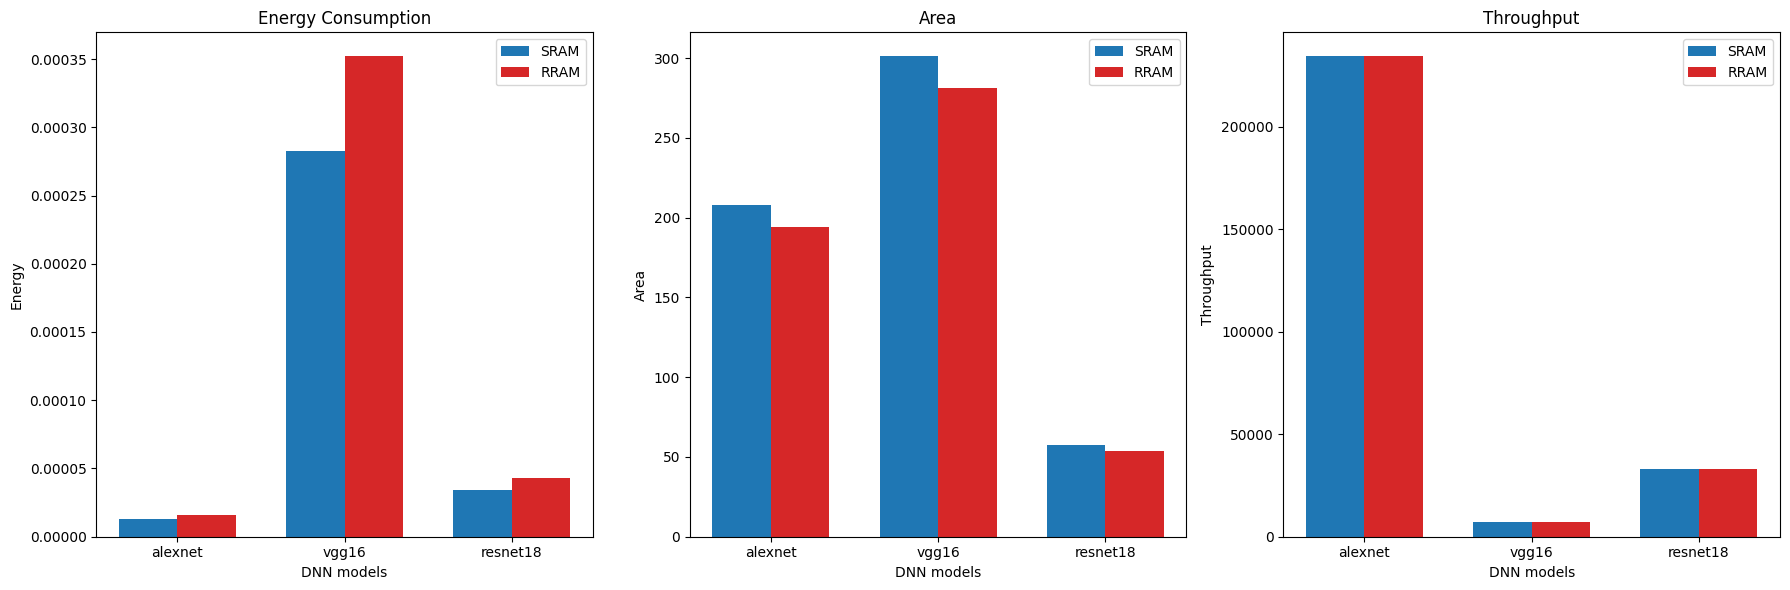

In [5]:
import matplotlib.pyplot as plt
import numpy as np

sram_label = "SRAM"
rram_label = "RRAM"

x = np.arange(len(dnn_list))  # Number of DNNs
width = 0.35  # Bar width

# Create figure and axes for three different plots (energy, area, throughput)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Energy Plot
ax1.bar(x - width/2, energy[::2], width, label=sram_label, color='tab:blue')  # SRAM for DNN1, DNN2
ax1.bar(x + width/2, energy[1::2], width, label=rram_label, color='tab:red')  # RRAM for DNN1, DNN2
ax1.set_title("Energy Consumption")
ax1.set_xticks(x)
ax1.set_xticklabels(dnn_list)
ax1.set_xlabel("DNN models")
ax1.set_ylabel("Energy")
ax1.legend()

# Area Plot
ax2.bar(x - width/2, total_area[::2], width, label=sram_label, color='tab:blue')  # SRAM for DNN1, DNN2
ax2.bar(x + width/2, total_area[1::2], width, label=rram_label, color='tab:red')  # RRAM for DNN1, DNN2
ax2.set_title("Area")
ax2.set_xticks(x)
ax2.set_xticklabels(dnn_list)
ax2.set_xlabel("DNN models")
ax2.set_ylabel("Area")
ax2.legend()

# Throughput Plot
ax3.bar(x - width/2, throughput[::2], width, label=sram_label, color='tab:blue')  # SRAM for DNN1, DNN2
ax3.bar(x + width/2, throughput[1::2], width, label=rram_label, color='tab:red')  # RRAM for DNN1, DNN2
ax3.set_title("Throughput")
ax3.set_xticks(x)
ax3.set_xticklabels(dnn_list)
ax3.set_xlabel("DNN models")
ax3.set_ylabel("Throughput")
ax3.legend()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [6]:
display_markdown(
    """
### Calculating the energy

"""
)

path_list = [SRAM_PATH, RRAM_PATH]  # List of paths
num_dnns = len(dnn_list)  # Get the number of DNN models
num_paths = len(path_list)  # Get the number of paths
num_cases = num_dnns * num_paths  # Total number of cases

# Initialize energy lists dynamically based on the number of cases
total_adc_energy = [0] * (2 * num_dnns)
total_col_energy = [0] * (2 * num_dnns)
total_row_energy = [0] * (2 * num_dnns)
total_cim_unit_energy = [0] * (2 * num_dnns)

# Iterate through all cases dynamically based on `j`
for j in range(2 * num_dnns):  # Now `j` will be 2 * number of DNN models
    # For each DNN model, calculate energy based on the path
    dnn_idx = j // 2  # Determine which DNN model (0 or 1, 2, etc.)
    path_idx = j % 2  # Determine which path (0 for SRAM, 1 for RRAM)

    # Now iterate through each energy category (ADC, Column, Row, CIM Unit)
    for i in range(4):  # Since there are 4 categories (ADC, Column, Row, CIM Unit)
        energy_value = total_per_energy[(dnn_list[dnn_idx], path_list[path_idx])][i] * energy[j]

        if i == 0:
            total_adc_energy[j] = energy_value
        elif i == 1:
            total_col_energy[j] = energy_value
        elif i == 2:
            total_row_energy[j] = energy_value
        else:
            total_cim_unit_energy[j] = energy_value

# Print the results for total energies
print("Total ADC Energy:", total_adc_energy)
print("Total Column Energy:", total_col_energy)
print("Total Row Energy:", total_row_energy)
print("Total CIM Unit Energy:", total_cim_unit_energy)


### Calculating the energy



Total ADC Energy: [5.307664156976354e-06, 5.263360217391308e-06, 0.0002128398890413509, 0.00024062851734689642, 1.736456334877991e-05, 1.8182034196889288e-05]
Total Column Energy: [3.7403002448491056e-08, 2.0982791739130452e-21, 1.4962326528130797e-06, 9.553311285712605e-20, 1.2211664468857414e-07, 7.22107618307352e-21]
Total Row Energy: [7.62308811807342e-06, 6.0758252173913095e-06, 6.798169590279467e-05, 6.177329102043202e-05, 1.7011625069335562e-05, 1.4264766666667547e-05]
Total CIM Unit Energy: [2.4472250173441455e-10, 4.9101145652173775e-06, 2.1824030413654743e-09, 4.956229163267142e-05, 4.849371959599224e-10, 1.0347499136443162e-05]


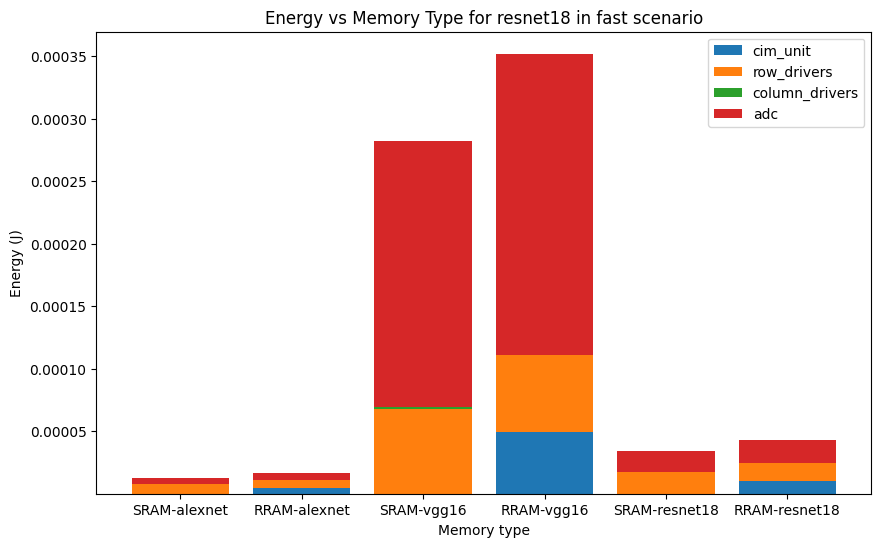

In [7]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(10, 6)) 
path = ['SRAM', 'RRAM']
num_bars = len(dnn_list) * len(path)

x = np.arange(num_bars)

# Stack bars
ax.bar(x, total_cim_unit_energy, label='cim_unit')
ax.bar(x, total_row_energy, bottom=total_cim_unit_energy, label='row_drivers')
ax.bar(x, total_col_energy, bottom=np.array(total_cim_unit_energy) + np.array(total_row_energy), label='column_drivers')
ax.bar(x, total_adc_energy, bottom=np.array(total_cim_unit_energy) + np.array(total_row_energy) + np.array(total_col_energy), label='adc')

# Labels and title
ax.set_title(f"Energy vs Memory Type for {DNN} in fast scenario")
ax.set_xlabel("Memory type")
ax.set_ylabel("Energy (J)")
# Set x-ticks
xtick_labels = [f"{mem}-{dnn}" for dnn in dnn_list for mem in path]
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels)

ax.legend()

# Show plot
plt.show()